In [11]:
import pandas as pd 
import datamol as dm
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

slurm_job_id = 155546
mode = 'fast' #quality or fast

smiles_col = 'smiles'
run_path = Path(f'/compchem/arc/users/dvik/repos/SyntheMol/runs/delqsar_real_rl_{mode}_{slurm_job_id}')


In [12]:
mol_df = pd.read_csv(run_path / "molecules.csv")

# concat the building block ids to get a unique identifier for each building block combination start with reaction_1_id, then building_block_1_1_id, then building_block_1_2_id, then building_block_1_3_id if it exists, if not just use the first two ids
mol_df['real_id'] = mol_df['reaction_1_id'].astype(str) + '__' + mol_df['building_block_1_1_id'].astype(str) + '__' + mol_df['building_block_1_2_id'].astype(str) + '__' + mol_df['building_block_1_3_id'].fillna('').astype(str)
# strip the trailing __ if building_block_1_3_id is missing
mol_df['real_id'] = mol_df['real_id'].str.rstrip('__')

mol_df


,smiles,node_id,num_expansions,rollout_num,score,Score 1,Score 2,Score 3,Q_value,num_reactions,reaction_1_chemical_space,reaction_1_id,building_block_1_1_id,building_block_1_1_smiles,building_block_1_2_id,building_block_1_2_smiles,building_block_1_3_id,building_block_1_3_smiles,real_id
0,N#Cc1c(-c2cc(F)cc(F)c2)nc2ccc(F)cc2c1-c1ccccc1,2050,3,924,5.543714,10.324355,0.449006,5.85778,5.543714,1,real,42,3944071,Nc1ccc(F)cc1C(=O)c1ccccc1,2203522,N#CCC(=O)c1cc(F)cc(F)c1,NaN,NaN,42__3944071__2203522
1,N#Cc1c(-c2cc(F)cc(F)c2)nc2ccc(Cl)cc2c1-c1ccccc1Cl,2187,1,998,5.480401,9.060444,0.355280,7.02548,5.480401,1,real,42,4437,Nc1ccc(Cl)cc1C(=O)c1ccccc1Cl,2203522,N#CCC(=O)c1cc(F)cc(F)c1,NaN,NaN,42__4437__2203522
2,Fc1cc(F)cc(-c2cc(-c3ccccc3Cl)c3cc(Cl)ccc3n2)c1,1745,8,716,5.438549,8.805449,0.356398,7.15380,5.438549,1,real,42,4437,Nc1ccc(Cl)cc1C(=O)c1ccccc1Cl,61785,CC(=O)c1cc(F)cc(F)c1,NaN,NaN,42__4437__61785
3,Fc1cc(F)cc(-c2cc(-c3ccccc3)c3cc(F)ccc3n2)c1,1527,12,617,5.338172,9.589828,0.438588,5.98610,5.338172,1,real,42,3944071,Nc1ccc(F)cc1C(=O)c1ccccc1,61785,CC(=O)c1cc(F)cc(F)c1,NaN,NaN,42__3944071__61785
4,Fc1ccc(-c2cc(-c3cc(F)cc(F)c3)nc3ccccc23)cc1,1751,4,719,5.283493,9.425791,0.438588,5.98610,5.283493,1,real,42,7617722,Nc1ccccc1C(=O)c1ccc(F)cc1,61785,CC(=O)c1cc(F)cc(F)c1,NaN,NaN,42__7617722__61785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,N[C@H]1C[C@H](c2nccn2C(=O)C2=NN(CCO)C(=O)CC2)C1,2026,1,914,0.297350,0.400971,0.792379,-0.30130,0.297350,1,real,22,26559049,N[C@H]1C[C@H](c2ncc[nH]2)C1,93341,O=C(O)C1=NN(CCO)C(=O)CC1,NaN,NaN,22__26559049__93341
996,Cc1nc(C#N)c(NCCC(=O)N(C)CC(=O)N2CCOCC2)o1,1906,1,855,0.272156,0.065680,0.776887,-0.02610,0.272156,1,real,22,219787,CNCC(=O)N1CCOCC1,26335050,Cc1nc(C#N)c(NCCC(=O)O)o1,NaN,NaN,22__219787__26335050
997,O=C(CS(=O)CC(F)(F)F)NC1CN(S(=O)(=O)C(F)(F)F)C1,559,1,23,0.211339,0.004371,0.682247,-0.05260,0.211339,1,real,22,26761014,NC1CN(S(=O)(=O)C(F)(F)F)C1,3728445,O=C(O)CS(=O)CC(F)(F)F,NaN,NaN,22__26761014__3728445
998,CNC(=O)CN(C)S(=O)(=O)CC(OC)C1CCOC1,588,1,34,-0.059259,0.122799,0.653922,-0.95450,-0.059259,1,real,40,31251,CNCC(=O)NC,22978002,COC(CS(=O)(=O)Cl)C1CCOC1,NaN,NaN,40__31251__22978002


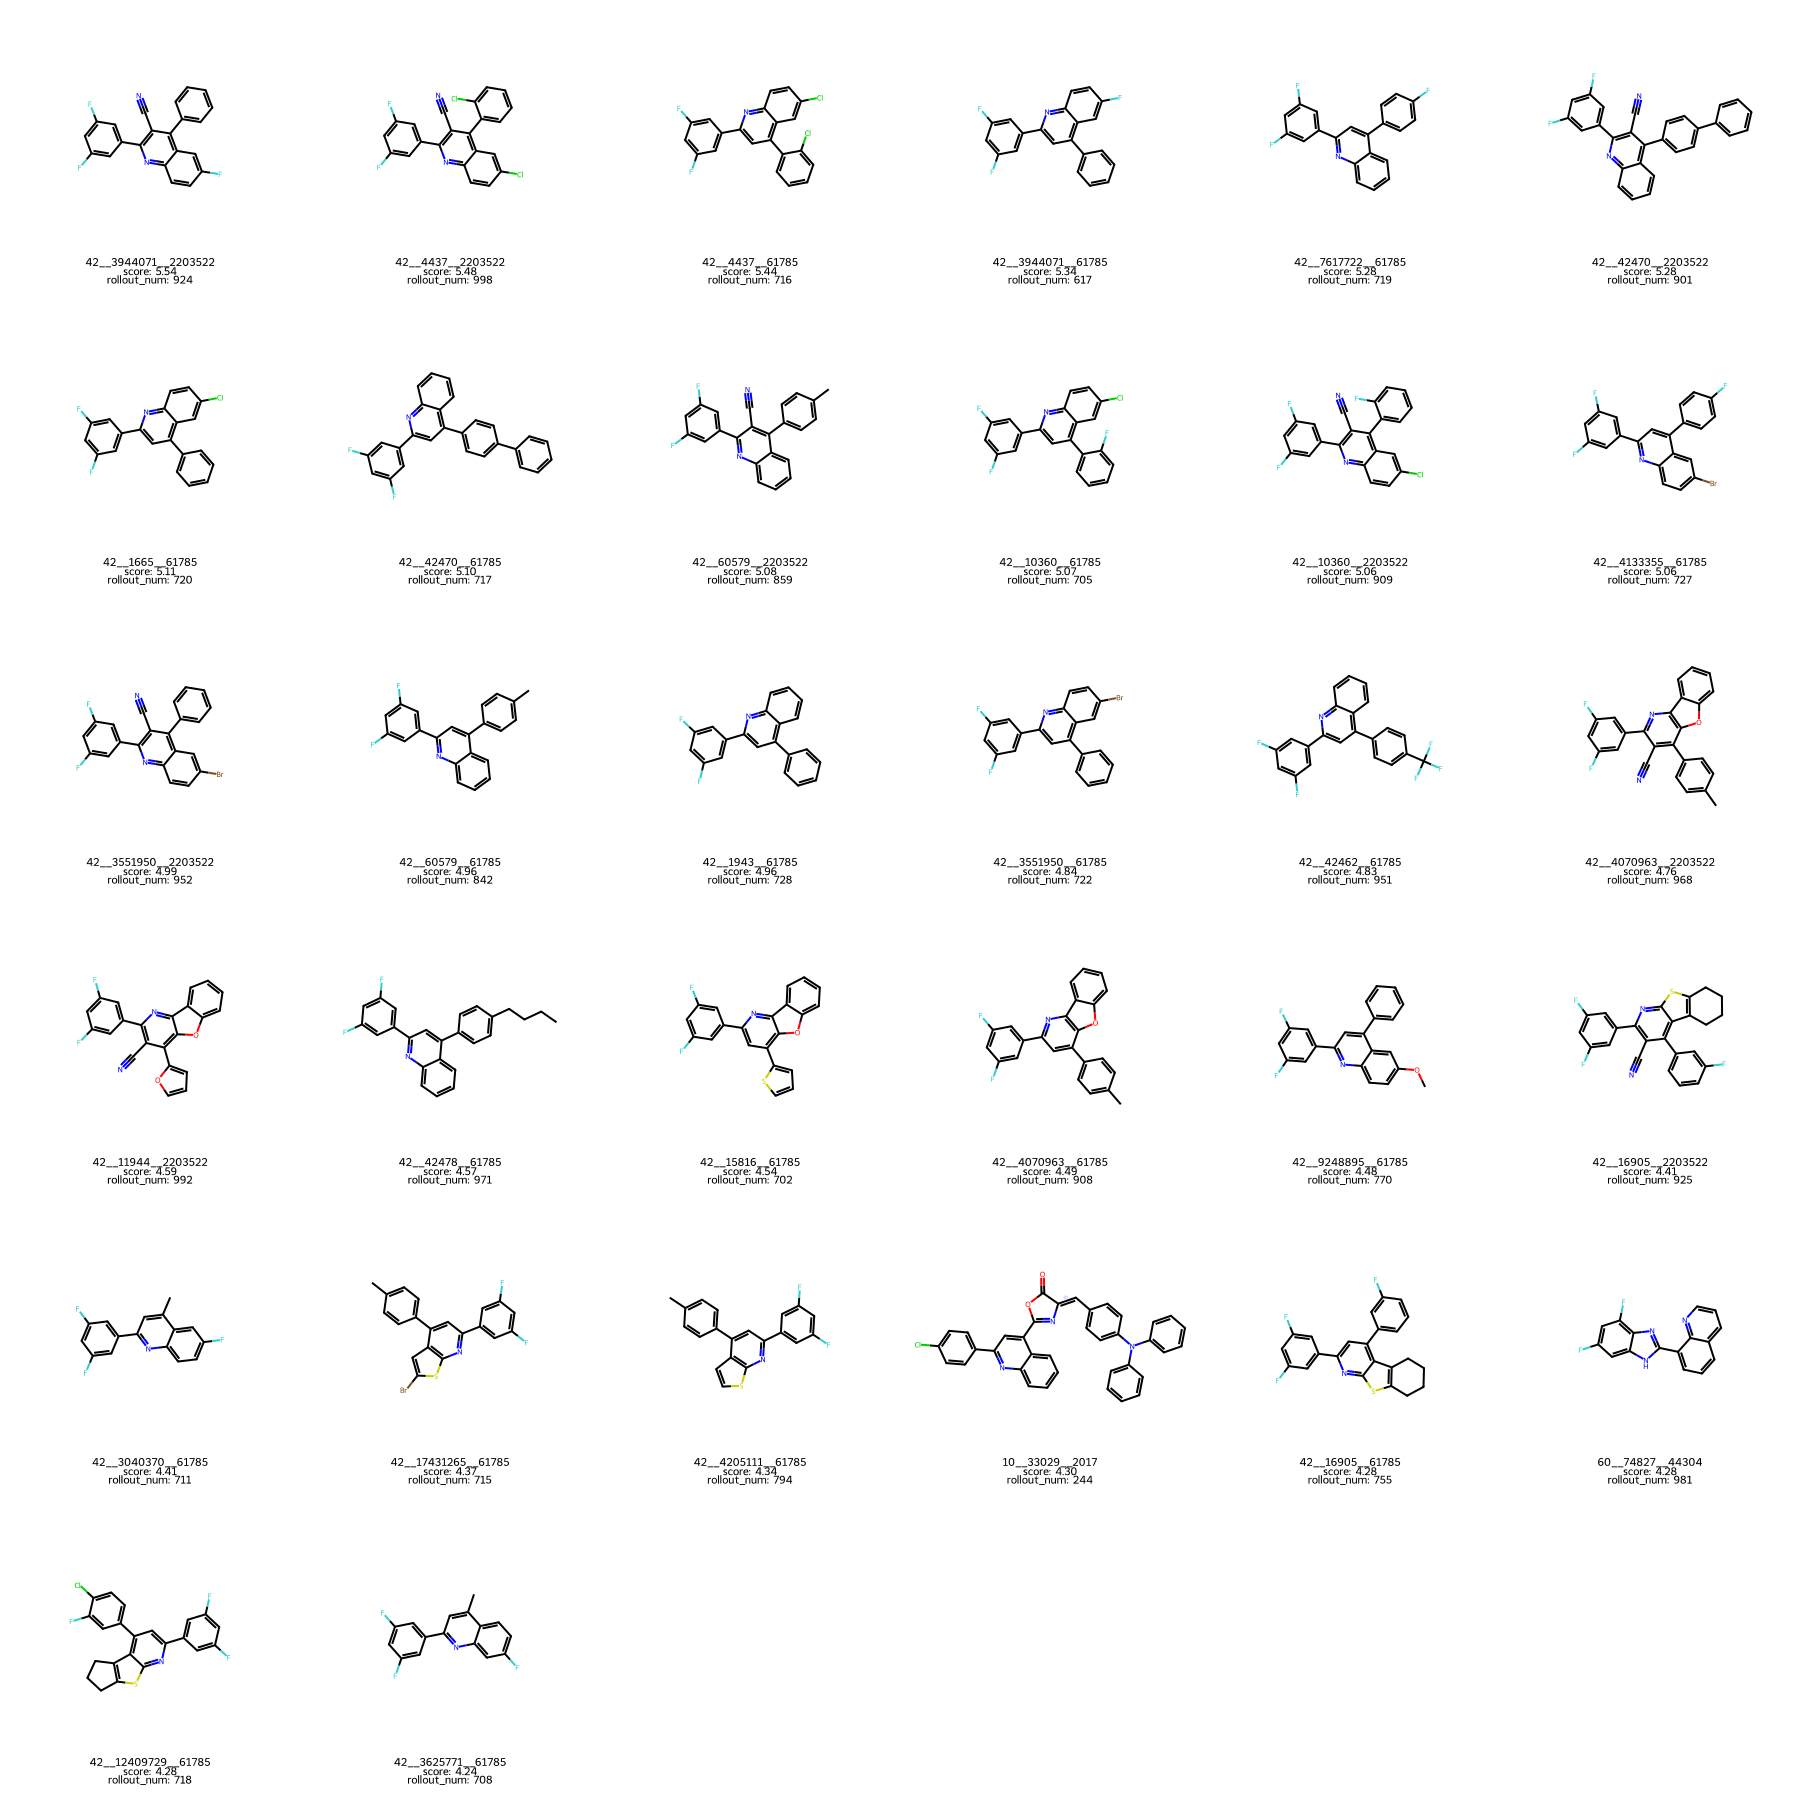

In [13]:

mols = [dm.to_mol(smiles) for smiles in mol_df[smiles_col]]

legend = [f"{fc}\nscore: {log2fc:.2f}\nrollout_num: {fdr:.0f}" for fc, log2fc, fdr in zip(mol_df['real_id'], mol_df['score'], mol_df['rollout_num'])]

dm.to_image(mols, legends=legend, n_cols = 6)